In [1]:
from rdkit import Chem
import matplotlib.pyplot as plt
import pandas as pd
from rdkit import Chem
from IPython.display import HTML
import pandas as pd
import numpy as np
from rdkit import rdBase, Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors
import statsmodels.api as sm

In [2]:

def df2df(df):

    adopt_list_alpha =['NumSaturatedRings',
                         'MolMR',
                         'fr_NH0',
                         'fr_NH1',
                         'fr_NH2',
                         'fr_allylic_oxid',
                         'fr_ester',
                         'fr_ketone',
                         'fr_methoxy',
                         'fr_sulfone',
                         'unbrch-Vol'
                      ]
    adopt_list_V = ['fr_C_O_noCOO',
                     'fr_allylic_oxid',
                     'fr_benzene',
                     'fr_ester',
                     'fr_sulfone',
                     'rdkit-Calculated_Volume',
                     'unbrch-Vol'
                   ]
    


    df_alpha =df[adopt_list_alpha]
    df_V = df[adopt_list_V]

    return df_alpha, df_V

In [3]:

def N_predictor(SMILES):
    path_model_alpha = "model_alpha_VIF_2025-10-10.pkl"
    path_model_V = "model_V_VIF_2025-10-10.pkl"
    

    Volume_list_test=[]

    false_list_test=[]

    data_frame_trying=pd.DataFrame([])
    data_frame_smiles=pd.DataFrame([SMILES], columns=["SMILES"])
    data_frame_trying=pd.concat([data_frame_trying, data_frame_smiles], axis=1)
    smiles=data_frame_trying["SMILES"].to_list()[0]
    try:
        params = Chem.SmilesParserParams()
        params.removeHs = False
        m = Chem.MolFromSmiles(smiles,params)
        mol= Chem.AddHs(m)
        AllChem.EmbedMolecule(mol,useRandomCoords=True)
        #AllChem.EmbedMolecule(mol)#,maxAttempts=5000)
        Volume_list_test.append(AllChem.ComputeMolVolume(mol))
    except RuntimeError:
        try:
            params = Chem.SmilesParserParams()
            params.removeHs = False
            m = Chem.MolFromSmiles(smiles,params)
            mol= Chem.AddHs(m)
            #AllChem.EmbedMolecule(mol,useRandomCoords=True)
            AllChem.EmbedMolecule(mol,maxAttempts=5000)
            Volume_list_test.append(AllChem.ComputeMolVolume(mol))
        except RuntimeError:
            false_list_test.append(smiles)
    print("Volume_list_test", Volume_list_test)
    print("false_list_test", false_list_test)

    # df_volumelist_test=pd.DataFrame(Volume_list_test, columns=["Calculated_Volume"])
    df_volumelist_test=pd.DataFrame(Volume_list_test, columns=["rdkit-Calculated_Volume"])
    data_frame_trying=pd.concat([data_frame_trying, df_volumelist_test], axis=1)
    
    PandasTools.AddMoleculeColumnToFrame(data_frame_trying,'SMILES','Molecule',includeFingerprints=True)
    data_frame_trying.head()
    
    
    descriptors_list2=pd.DataFrame(Descriptors._descList)
    a1=descriptors_list2[0]
    calc = MoleculeDescriptors.MolecularDescriptorCalculator(a1)
    descs = [calc.CalcDescriptors(mol) for mol in data_frame_trying["Molecule"]]
    
    df_deicriptors=pd.DataFrame(descs)
    df_deicriptors.head()
    
    for i in range(0, 210, 1):
        df_deicriptors=df_deicriptors.rename(columns={i:a1[i]})
    df_deicriptors.head()
    
    
    data_frame_trying=pd.concat([data_frame_trying, df_deicriptors], axis=1)
    new_column = pd.DataFrame(data_frame_trying["fr_unbrch_alkane"]*data_frame_trying["rdkit-Calculated_Volume"], columns=["unbrch-Vol"])
    data_frame_trying = pd.concat([data_frame_trying, new_column], axis=1)

    adopt_list_alpha = ['NumSaturatedRings',
                         'MolMR',
                         'fr_NH0',
                         'fr_NH1',
                         'fr_NH2',
                         'fr_allylic_oxid',
                         'fr_benzene',
                         'fr_ester',
                         'fr_halogen',
                         'fr_ketone',
                         'fr_methoxy',
                         'fr_sulfone']

    df_alpha, df_V = df2df(data_frame_trying)
    
    return df_alpha, df_V
    

In [4]:
data_train = pd.read_csv("train_for_publication.csv")

data_train = data_train[["SMILES", "refractive_index", "density"]]

data_train

,SMILES,refractive_index,density
0,[*]C(C(O[*])=O)C,1.4700,1.2600
1,[*]C(C)(C)C[*],1.5075,0.8750
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050
3,[*]C/C=C(C[*])\C,1.5150,0.9050
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700
6,[*]CC([*])c1ccccc1,1.5250,1.0500
7,[*]CC(C=C)[*],1.5400,0.9100
8,[*]CO[*],1.4950,1.2250
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650


In [5]:
from rdkit import Chem
import matplotlib.pyplot as plt
import pandas as pd

## test_data

In [6]:
data_test = pd.read_csv("test_for_publication.csv")
data_test

,Unnamed: 0,title,SMILES,Experimental n,Predicted density,reference
0,0,mPhThiourea,[*]C1=CC(NC(N[*])=S)=CC=C1,1.79,1.399676,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ..."
1,1,PPO,[*]OC1=C(C)C=C([*])C=C1C,1.58,1.140495,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,..."
2,2,mXThiourea,[*]NC(NCC1=CC=CC(C[*])=C1)=S,1.70,1.243807,"S. Watanabe, Y. Tsunekawa, K. Oyaizu, Chem. Co..."
3,3,PPOPMPS1_3535,[*]SC1=CC(C)=C(OC2=CC(C)=C([*])C(C)=C2)C(C)=C1,1.64,1.100088,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,..."
4,4,PPOPMPS2_3526,[*]SC1=C(C)C=C(OC2=CC(C)=C([*])C(C)=C2)C=C1C,1.66,1.076703,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,..."
5,5,Dibenzothiophene_PPS,[*]SC1=CC=C2C(C3=CC([*])=CC=C3S2)=C1,1.85,1.356455,"S. Watanabe, Z. An, H. Nishio, Y. Tsunekawa, K..."
6,6,nh pps b,S=C(NC1=CC=C(C=C1)SC2=CC=C(C=C2)[*])N[*],1.83,1.339596,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ..."
7,7,FluoreneThiourea,[*]NC(NC1=CC=C(C2(C3=CC=C([*])C=C3)C4=C(C5=C2C...,1.72,1.122378,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ..."
8,8,mpPhThiourea,S=C(NC1=CC=C(C=C1)NC(NC2=CC([*])=CC=C2)=S)N[*],1.81,1.235075,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ..."
9,9,diMeBiPhThiourea,[*]NC(NC1=CC=C(C2=CC=C([*])C=C2C)C(C)=C1)=S,1.75,1.098646,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ..."


In [7]:
from rdkit import Chem
from IPython.display import HTML
import pandas as pd
import numpy as np
from rdkit import rdBase, Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, PandasTools
from rdkit.ML.Descriptors import MoleculeDescriptors

list_smiles_train=[]
list_smiles_test=[]
for i in data_train["SMILES"]:
    list_smiles_train.append(i)

list_smiles_test = pd.Series(data_test["SMILES"]).to_list()


Volume_list_train=[]
Volume_list_test=[]
false_list_train=[]
false_list_test=[]
for i in list_smiles_train:
    try:
        params = Chem.SmilesParserParams()
        params.removeHs = False
        m = Chem.MolFromSmiles(i,params)
        mol= Chem.AddHs(m)
        AllChem.EmbedMolecule(mol,useRandomCoords=True)
        Volume_list_train.append(AllChem.ComputeMolVolume(mol))
    except RuntimeError:
        try:
            params = Chem.SmilesParserParams()
            params.removeHs = False
            m = Chem.MolFromSmiles(i,params)
            mol= Chem.AddHs(m)
            AllChem.EmbedMolecule(mol,maxAttempts=5000)
            Volume_list_train.append(AllChem.ComputeMolVolume(mol))
        except RuntimeError:
            false_list_train.append(i)
print("Volume_list_train", Volume_list_train)
print("false_list_train", false_list_train)

[22:33:37] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (4)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (5)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (11)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (5)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (21)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:37] UFFTYPER: Unrecognized atom type: *_ (23)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (3)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (5)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (3)
[22:33:38] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:38

Volume_list_train [69.80000000000001, 74.42400000000002, 169.23200000000003, 85.65600000000002, 344.7360000000001, 380.2720000000001, 112.39200000000002, 68.38400000000001, 33.06400000000001, 257.4800000000001, 83.27200000000002, 57.88000000000002, 107.03200000000002, 75.97600000000001, 128.26400000000004, 120.22400000000003, 74.48800000000001, 174.16800000000003, 203.38400000000004, 136.33600000000004, 103.65600000000002, 118.84000000000003, 83.79200000000002, 127.40000000000003, 87.30400000000002, 103.84800000000003, 73.06400000000002, 52.10400000000001, 59.368000000000016, 73.72000000000001, 223.96000000000006, 123.07200000000003, 118.81600000000003, 123.20800000000003, 238.39200000000005, 302.16800000000006, 336.1040000000001, 175.28000000000003, 158.04000000000005, 70.36800000000002]
false_list_train []


[22:33:43] UFFTYPER: Unrecognized atom type: *_ (3)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (5)


In [8]:
list_smiles_test

['[*]C1=CC(NC(N[*])=S)=CC=C1',
 '[*]OC1=C(C)C=C([*])C=C1C',
 '[*]NC(NCC1=CC=CC(C[*])=C1)=S',
 '[*]SC1=CC(C)=C(OC2=CC(C)=C([*])C(C)=C2)C(C)=C1',
 '[*]SC1=C(C)C=C(OC2=CC(C)=C([*])C(C)=C2)C=C1C',
 '[*]SC1=CC=C2C(C3=CC([*])=CC=C3S2)=C1',
 'S=C(NC1=CC=C(C=C1)SC2=CC=C(C=C2)[*])N[*]',
 '[*]NC(NC1=CC=C(C2(C3=CC=C([*])C=C3)C4=C(C5=C2C=CC=C5)C=CC=C4)C=C1)=S',
 'S=C(NC1=CC=C(C=C1)NC(NC2=CC([*])=CC=C2)=S)N[*]',
 '[*]NC(NC1=CC=C(C2=CC=C([*])C=C2C)C(C)=C1)=S',
 'S=C(N[*])NC1=CC=C(NC(NC2=CC=C(C=C2)SC3=CC=C(C=C3)[*])=S)C=C1']

In [9]:
for i in list_smiles_test:
    try:
        params = Chem.SmilesParserParams()
        params.removeHs = False
        m = Chem.MolFromSmiles(i,params)
        mol= Chem.AddHs(m)
        AllChem.EmbedMolecule(mol,useRandomCoords=True)
        Volume_list_test.append(AllChem.ComputeMolVolume(mol))
    except RuntimeError:
        try:
            params = Chem.SmilesParserParams()
            params.removeHs = False
            m = Chem.MolFromSmiles(i,params)
            mol= Chem.AddHs(m)
            AllChem.EmbedMolecule(mol,maxAttempts=5000)
            Volume_list_test.append(AllChem.ComputeMolVolume(mol))
        except RuntimeError:
            false_list_test.append(i)
print("Volume_list_test", Volume_list_test)
print("false_list_test", false_list_test)

[22:33:43] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (7)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (7)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (11)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:43] UFFTYPER: Unrecognized atom type: *_ (13)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (13)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (10)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (16)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (18)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:44] UFFTYPER: Unrecognized atom type: *_ (13)
[22:33:45] UFFTYPER: Unrecognized atom type: *_ (15)
[22:33:45] UFFTYPER: Unrecognized atom type: *_ (21)
[22:33:45] UFFTYPER: Unrecognized atom type: *_ (0)
[22

Volume_list_test [130.31200000000004, 120.31200000000003, 164.29600000000005, 243.12000000000006, 243.35200000000006, 174.18400000000005, 219.68000000000006, 346.0080000000001, 255.29600000000005, 235.55200000000005, 344.3760000000001]
false_list_test []


In [10]:
df_volumelist_train=pd.DataFrame(Volume_list_train, columns=["rdkit-Calculated_Volume"])
df_volumelist_train

,rdkit-Calculated_Volume
0,69.800
1,74.424
2,169.232
3,85.656
4,344.736
5,380.272
6,112.392
7,68.384
8,33.064
9,257.480


In [11]:
df_volumelist_test=pd.DataFrame(Volume_list_test, columns=["rdkit-Calculated_Volume"])
df_volumelist_test

,rdkit-Calculated_Volume
0,130.312
1,120.312
2,164.296
3,243.120
4,243.352
5,174.184
6,219.680
7,346.008
8,255.296
9,235.552


In [12]:
data_train_merged=pd.merge(data_train, df_volumelist_train, right_index=True, left_index=True)
data_train_merged

,SMILES,refractive_index,density,rdkit-Calculated_Volume
0,[*]C(C(O[*])=O)C,1.4700,1.2600,69.800
1,[*]C(C)(C)C[*],1.5075,0.8750,74.424
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050,169.232
3,[*]C/C=C(C[*])\C,1.5150,0.9050,85.656
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900,344.736
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700,380.272
6,[*]CC([*])c1ccccc1,1.5250,1.0500,112.392
7,[*]CC(C=C)[*],1.5400,0.9100,68.384
8,[*]CO[*],1.4950,1.2250,33.064
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650,257.480


In [13]:
data_test_merged=pd.merge(data_test.reset_index(drop=True), df_volumelist_test.reset_index(drop=True), right_index=True, left_index=True)
data_test_merged

,Unnamed: 0,title,SMILES,Experimental n,Predicted density,reference,rdkit-Calculated_Volume
0,0,mPhThiourea,[*]C1=CC(NC(N[*])=S)=CC=C1,1.79,1.399676,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",130.312
1,1,PPO,[*]OC1=C(C)C=C([*])C=C1C,1.58,1.140495,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",120.312
2,2,mXThiourea,[*]NC(NCC1=CC=CC(C[*])=C1)=S,1.70,1.243807,"S. Watanabe, Y. Tsunekawa, K. Oyaizu, Chem. Co...",164.296
3,3,PPOPMPS1_3535,[*]SC1=CC(C)=C(OC2=CC(C)=C([*])C(C)=C2)C(C)=C1,1.64,1.100088,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",243.120
4,4,PPOPMPS2_3526,[*]SC1=C(C)C=C(OC2=CC(C)=C([*])C(C)=C2)C=C1C,1.66,1.076703,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",243.352
5,5,Dibenzothiophene_PPS,[*]SC1=CC=C2C(C3=CC([*])=CC=C3S2)=C1,1.85,1.356455,"S. Watanabe, Z. An, H. Nishio, Y. Tsunekawa, K...",174.184
6,6,nh pps b,S=C(NC1=CC=C(C=C1)SC2=CC=C(C=C2)[*])N[*],1.83,1.339596,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",219.680
7,7,FluoreneThiourea,[*]NC(NC1=CC=C(C2(C3=CC=C([*])C=C3)C4=C(C5=C2C...,1.72,1.122378,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",346.008
8,8,mpPhThiourea,S=C(NC1=CC=C(C=C1)NC(NC2=CC([*])=CC=C2)=S)N[*],1.81,1.235075,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",255.296
9,9,diMeBiPhThiourea,[*]NC(NC1=CC=C(C2=CC=C([*])C=C2C)C(C)=C1)=S,1.75,1.098646,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",235.552


In [14]:
from rdkit import Chem
from IPython.display import HTML
import pandas as pd
import numpy as np
from rdkit import rdBase, Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, PandasTools

PandasTools.AddMoleculeColumnToFrame(data_train_merged,'SMILES','Molecule',includeFingerprints=True)
data_train_merged.head()
data_train_merged

descriptors_list2=pd.DataFrame(Descriptors._descList)
a1=descriptors_list2[0]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(a1)
descs = [calc.CalcDescriptors(mol) for mol in data_train_merged["Molecule"]]

df_deicriptors=pd.DataFrame(descs)
df_deicriptors.head()

for i in range(0, 210, 1):
    df_deicriptors=df_deicriptors.rename(columns={i:a1[i]})
df_deicriptors.head()


df_train_merged_merged=pd.merge(data_train_merged.reset_index(drop=True), df_deicriptors.reset_index(drop=True), right_index=True, left_index=True)
df_train_merged_merged

[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerat

,SMILES,refractive_index,density,rdkit-Calculated_Volume,Molecule,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,[*]C(C(O[*])=O)C,1.4700,1.2600,69.800,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,10.414352,10.414352,0.069444,-0.134907,0.446475,...,0,0,0,0,0,0,0,0,0,0
1,[*]C(C)(C)C[*],1.5075,0.8750,74.424,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.416667,2.416667,0.659722,0.659722,0.428640,...,0,0,0,0,0,0,0,0,0,0
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050,169.232,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,11.473978,11.473978,0.076163,-0.361858,0.515786,...,0,0,0,0,0,0,0,0,0,0
3,[*]C/C=C(C[*])\C,1.5150,0.9050,85.656,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.437500,2.437500,0.655926,0.655926,0.433192,...,0,0,0,0,0,0,0,0,0,0
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900,344.736,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.802425,12.802425,0.066562,-3.519497,0.457223,...,0,0,1,0,0,0,0,0,0,0
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700,380.272,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.850652,12.850652,0.027803,-3.658176,0.408199,...,0,0,2,0,0,0,0,0,0,0
6,[*]CC([*])c1ccccc1,1.5250,1.0500,112.392,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.291157,2.291157,0.554259,0.554259,0.539443,...,0,0,0,0,0,0,0,0,0,0
7,[*]CC(C=C)[*],1.5400,0.9100,68.384,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,3.733935,3.733935,0.625000,0.625000,0.418693,...,0,0,0,0,0,0,0,0,0,0
8,[*]CO[*],1.4950,1.2250,33.064,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,4.902778,4.902778,0.319444,0.319444,0.393176,...,0,0,0,0,0,0,0,0,0,0
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650,257.480,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.469368,12.469368,0.040275,-0.100005,0.671071,...,0,0,0,0,0,0,0,0,0,0


In [15]:
from rdkit import Chem
from IPython.display import HTML
import pandas as pd
import numpy as np
from rdkit import rdBase, Chem, DataStructs
from rdkit.Chem import AllChem, Draw, Descriptors, PandasTools

PandasTools.AddMoleculeColumnToFrame(data_test_merged,'SMILES','Molecule',includeFingerprints=True)
data_test_merged.head()
data_test_merged

descriptors_list2=pd.DataFrame(Descriptors._descList)
a1=descriptors_list2[0]
calc = MoleculeDescriptors.MolecularDescriptorCalculator(a1)
descs = [calc.CalcDescriptors(mol) for mol in data_test_merged["Molecule"]]

df_deicriptors=pd.DataFrame(descs)
df_deicriptors.head()

for i in range(0, 210, 1):
    df_deicriptors=df_deicriptors.rename(columns={i:a1[i]})
df_deicriptors.head()


df_test_merged_merged=pd.merge(data_test_merged.reset_index(drop=True), df_deicriptors.reset_index(drop=True), right_index=True, left_index=True)
df_test_merged_merged

[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerator
[22:33:46] DEPRECATION WARNING: please use MorganGenerat

,Unnamed: 0,title,SMILES,Experimental n,Predicted density,reference,rdkit-Calculated_Volume,Molecule,MaxAbsEStateIndex,MaxEStateIndex,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,mPhThiourea,[*]C1=CC(NC(N[*])=S)=CC=C1,1.79,1.399676,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",130.312,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.041213,5.041213,...,0,0,0,0,0,0,0,0,0,0
1,1,PPO,[*]OC1=C(C)C=C([*])C=C1C,1.58,1.140495,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",120.312,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.508519,5.508519,...,0,0,0,0,0,0,0,0,0,0
2,2,mXThiourea,[*]NC(NCC1=CC=CC(C[*])=C1)=S,1.70,1.243807,"S. Watanabe, Y. Tsunekawa, K. Oyaizu, Chem. Co...",164.296,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.068249,5.068249,...,0,0,0,0,0,0,0,0,0,0
3,3,PPOPMPS1_3535,[*]SC1=CC(C)=C(OC2=CC(C)=C([*])C(C)=C2)C(C)=C1,1.64,1.100088,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",243.120,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,6.195002,6.195002,...,0,0,0,0,0,0,0,0,0,0
4,4,PPOPMPS2_3526,[*]SC1=C(C)C=C(OC2=CC(C)=C([*])C(C)=C2)C=C1C,1.66,1.076703,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",243.352,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,6.095094,6.095094,...,0,0,0,0,0,0,0,0,0,0
5,5,Dibenzothiophene_PPS,[*]SC1=CC=C2C(C3=CC([*])=CC=C3S2)=C1,1.85,1.356455,"S. Watanabe, Z. An, H. Nishio, Y. Tsunekawa, K...",174.184,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,2.421473,2.421473,...,0,0,0,0,0,0,0,1,0,0
6,6,nh pps b,S=C(NC1=CC=C(C=C1)SC2=CC=C(C=C2)[*])N[*],1.83,1.339596,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",219.680,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.128222,5.128222,...,0,0,0,0,0,0,0,0,0,0
7,7,FluoreneThiourea,[*]NC(NC1=CC=C(C2(C3=CC=C([*])C=C3)C4=C(C5=C2C...,1.72,1.122378,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",346.008,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.338297,5.338297,...,0,0,0,0,0,0,0,0,0,0
8,8,mpPhThiourea,S=C(NC1=CC=C(C=C1)NC(NC2=CC([*])=CC=C2)=S)N[*],1.81,1.235075,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",255.296,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.342914,5.342914,...,0,0,0,0,0,0,0,0,0,0
9,9,diMeBiPhThiourea,[*]NC(NC1=CC=C(C2=CC=C([*])C=C2C)C(C)=C1)=S,1.75,1.098646,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",235.552,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.189173,5.189173,...,0,0,0,0,0,0,0,0,0,0


## alpha converter

In [16]:
def alpha_converter(data_input, n_name, d_name):
    refractive_index=data_input[n_name].to_numpy()
    DFT_based_density=data_input[d_name].to_numpy()
    Mw=data_input["MolWt"].to_numpy()
    N_A=6.02e23
    epsilon=8.854e-12
    alpha_from_DFT_based_density=(3*epsilon*Mw/(DFT_based_density*N_A))*((refractive_index**2-1)/(refractive_index**2+2))
    alpha_from_DFT_based_density=alpha_from_DFT_based_density*1e33
    return alpha_from_DFT_based_density

In [17]:
df_train_merged_merged

,SMILES,refractive_index,density,rdkit-Calculated_Volume,Molecule,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,[*]C(C(O[*])=O)C,1.4700,1.2600,69.800,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,10.414352,10.414352,0.069444,-0.134907,0.446475,...,0,0,0,0,0,0,0,0,0,0
1,[*]C(C)(C)C[*],1.5075,0.8750,74.424,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.416667,2.416667,0.659722,0.659722,0.428640,...,0,0,0,0,0,0,0,0,0,0
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050,169.232,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,11.473978,11.473978,0.076163,-0.361858,0.515786,...,0,0,0,0,0,0,0,0,0,0
3,[*]C/C=C(C[*])\C,1.5150,0.9050,85.656,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.437500,2.437500,0.655926,0.655926,0.433192,...,0,0,0,0,0,0,0,0,0,0
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900,344.736,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.802425,12.802425,0.066562,-3.519497,0.457223,...,0,0,1,0,0,0,0,0,0,0
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700,380.272,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.850652,12.850652,0.027803,-3.658176,0.408199,...,0,0,2,0,0,0,0,0,0,0
6,[*]CC([*])c1ccccc1,1.5250,1.0500,112.392,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.291157,2.291157,0.554259,0.554259,0.539443,...,0,0,0,0,0,0,0,0,0,0
7,[*]CC(C=C)[*],1.5400,0.9100,68.384,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,3.733935,3.733935,0.625000,0.625000,0.418693,...,0,0,0,0,0,0,0,0,0,0
8,[*]CO[*],1.4950,1.2250,33.064,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,4.902778,4.902778,0.319444,0.319444,0.393176,...,0,0,0,0,0,0,0,0,0,0
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650,257.480,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.469368,12.469368,0.040275,-0.100005,0.671071,...,0,0,0,0,0,0,0,0,0,0


In [18]:
alpha_train=alpha_converter(df_train_merged_merged, "refractive_index", "density")
alpha_train

array([0.70406638, 0.84269461, 1.98002097, 1.00148227, 5.11656608,
       4.76597365, 1.34126445, 0.82289228, 0.3153882 , 3.75639892,
       0.92698889, 0.61519546, 1.22944998, 0.85213695, 1.64458597,
       1.30107145, 0.84765082, 1.99512237, 2.27242062, 1.44759578,
       1.09036298, 1.25629895, 1.01116753, 1.7032245 , 0.8730281 ,
       1.10572089, 0.72993144, 0.43573961, 0.58851805, 0.64832422,
       2.6681584 , 1.34819662, 1.22613846, 1.39858544, 2.8561438 ,
       3.75946245, 3.96065179, 2.01827579, 2.04165051, 0.72317074])

In [19]:
df_test_merged_merged

,Unnamed: 0,title,SMILES,Experimental n,Predicted density,reference,rdkit-Calculated_Volume,Molecule,MaxAbsEStateIndex,MaxEStateIndex,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,mPhThiourea,[*]C1=CC(NC(N[*])=S)=CC=C1,1.79,1.399676,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",130.312,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.041213,5.041213,...,0,0,0,0,0,0,0,0,0,0
1,1,PPO,[*]OC1=C(C)C=C([*])C=C1C,1.58,1.140495,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",120.312,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.508519,5.508519,...,0,0,0,0,0,0,0,0,0,0
2,2,mXThiourea,[*]NC(NCC1=CC=CC(C[*])=C1)=S,1.70,1.243807,"S. Watanabe, Y. Tsunekawa, K. Oyaizu, Chem. Co...",164.296,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.068249,5.068249,...,0,0,0,0,0,0,0,0,0,0
3,3,PPOPMPS1_3535,[*]SC1=CC(C)=C(OC2=CC(C)=C([*])C(C)=C2)C(C)=C1,1.64,1.100088,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",243.120,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,6.195002,6.195002,...,0,0,0,0,0,0,0,0,0,0
4,4,PPOPMPS2_3526,[*]SC1=C(C)C=C(OC2=CC(C)=C([*])C(C)=C2)C=C1C,1.66,1.076703,"S. Watanabe, S. Miura, T. Miura, Y. Tsunekawa,...",243.352,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,6.095094,6.095094,...,0,0,0,0,0,0,0,0,0,0
5,5,Dibenzothiophene_PPS,[*]SC1=CC=C2C(C3=CC([*])=CC=C3S2)=C1,1.85,1.356455,"S. Watanabe, Z. An, H. Nishio, Y. Tsunekawa, K...",174.184,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,2.421473,2.421473,...,0,0,0,0,0,0,0,1,0,0
6,6,nh pps b,S=C(NC1=CC=C(C=C1)SC2=CC=C(C=C2)[*])N[*],1.83,1.339596,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",219.680,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.128222,5.128222,...,0,0,0,0,0,0,0,0,0,0
7,7,FluoreneThiourea,[*]NC(NC1=CC=C(C2(C3=CC=C([*])C=C3)C4=C(C5=C2C...,1.72,1.122378,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",346.008,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.338297,5.338297,...,0,0,0,0,0,0,0,0,0,0
8,8,mpPhThiourea,S=C(NC1=CC=C(C=C1)NC(NC2=CC([*])=CC=C2)=S)N[*],1.81,1.235075,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",255.296,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.342914,5.342914,...,0,0,0,0,0,0,0,0,0,0
9,9,diMeBiPhThiourea,[*]NC(NC1=CC=C(C2=CC=C([*])C=C2C)C(C)=C1)=S,1.75,1.098646,"S. Watanabe, L. M. Cavinato, V. Calvi, R. van ...",235.552,<rdkit.Chem.rdchem.Mol object at 0x000002CBB9D...,5.189173,5.189173,...,0,0,0,0,0,0,0,0,0,0


In [20]:
df_test_merged_merged = df_test_merged_merged.rename(columns={"Experimental n": "refractive_index"})

In [21]:
alpha_test=alpha_converter(df_test_merged_merged, "refractive_index", "Predicted density")
alpha_test

array([2.00544004, 1.54696694, 2.4440947 , 3.70469405, 3.87843037,
       3.11439461, 3.73709735, 6.06342809, 4.62984779, 4.16179473,
       6.45942635])

In [22]:
alpha =np.concat([alpha_train, alpha_test])

In [23]:
data = pd.concat([df_train_merged_merged, df_test_merged_merged])
data = data.reset_index(drop=True)
data

,SMILES,refractive_index,density,rdkit-Calculated_Volume,Molecule,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,...,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea,Unnamed: 0,title,Predicted density,reference
0,[*]C(C(O[*])=O)C,1.4700,1.2600,69.800,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,10.414352,10.414352,0.069444,-0.134907,0.446475,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
1,[*]C(C)(C)C[*],1.5075,0.8750,74.424,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.416667,2.416667,0.659722,0.659722,0.428640,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050,169.232,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,11.473978,11.473978,0.076163,-0.361858,0.515786,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
3,[*]C/C=C(C[*])\C,1.5150,0.9050,85.656,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.437500,2.437500,0.655926,0.655926,0.433192,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900,344.736,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.802425,12.802425,0.066562,-3.519497,0.457223,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700,380.272,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.850652,12.850652,0.027803,-3.658176,0.408199,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
6,[*]CC([*])c1ccccc1,1.5250,1.0500,112.392,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,2.291157,2.291157,0.554259,0.554259,0.539443,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
7,[*]CC(C=C)[*],1.5400,0.9100,68.384,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,3.733935,3.733935,0.625000,0.625000,0.418693,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
8,[*]CO[*],1.4950,1.2250,33.064,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,4.902778,4.902778,0.319444,0.319444,0.393176,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650,257.480,<rdkit.Chem.rdchem.Mol object at 0x000002CBB96...,12.469368,12.469368,0.040275,-0.100005,0.671071,...,0,0,0,0,0,0,NaN,NaN,NaN,NaN


In [24]:
df_alpha_collector =pd.DataFrame([])
df_V_collector =pd.DataFrame([])
for smiles_chosen in data["SMILES"]:
    data_converted_alpha, data_converted_V = N_predictor(smiles_chosen)
    df_alpha_collector =pd.concat([df_alpha_collector, data_converted_alpha])
    df_V_collector =pd.concat([df_V_collector, data_converted_V])


[22:33:47] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:47] UFFTYPER: Unrecognized atom type: *_ (4)
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (5)


Volume_list_test [69.92000000000002]
false_list_test []
Volume_list_test [74.57600000000002]
false_list_test []


[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (11)


Volume_list_test [169.02400000000003]
false_list_test []
Volume_list_test [85.49600000000002]
false_list_test []


[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (5)
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] DEPRECATION WARNING: please use MorganGenerator
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (0)
[22:33:48] UFFTYPER: Unrecognized atom type: *_ (21)


...

[22:34:00] DEPRECATION WARNING: please use MorganGenerator
[22:34:00] DEPRECATION WARNING: please use MorganGenerator
[22:34:00] DEPRECATION WARNING: please use MorganGenerator
[22:34:00] UFFTYPER: Unrecognized atom type: *_ (0)
[22:34:00] UFFTYPER: Unrecognized atom type: *_ (12)


Volume_list_test [234.11200000000005]
false_list_test []


[22:34:00] DEPRECATION WARNING: please use MorganGenerator
[22:34:00] DEPRECATION WARNING: please use MorganGenerator
[22:34:00] DEPRECATION WARNING: please use MorganGenerator
[22:34:00] UFFTYPER: Unrecognized atom type: *_ (3)
[22:34:00] UFFTYPER: Unrecognized atom type: *_ (25)


Volume_list_test [342.1600000000001]
false_list_test []


[22:34:01] DEPRECATION WARNING: please use MorganGenerator
[22:34:01] DEPRECATION WARNING: please use MorganGenerator
[22:34:01] DEPRECATION WARNING: please use MorganGenerator


In [25]:
df_V_collector

,fr_C_O_noCOO,fr_allylic_oxid,fr_benzene,fr_ester,fr_sulfone,rdkit-Calculated_Volume,unbrch-Vol
0,1,0,0,0,0,69.920,0.000
0,0,0,0,0,0,74.576,0.000
0,2,0,1,1,0,169.024,0.000
0,0,2,0,0,0,85.496,0.000
0,0,0,4,0,1,344.456,0.000
0,0,0,4,0,2,380.904,0.000
0,0,0,1,0,0,111.864,0.000
0,0,1,0,0,0,69.112,0.000
0,0,0,0,0,0,33.048,0.000
0,1,0,3,0,0,258.208,0.000


In [26]:
df_alpha_collector

,NumSaturatedRings,MolMR,fr_NH0,fr_NH1,fr_NH2,fr_allylic_oxid,fr_ester,fr_ketone,fr_methoxy,fr_sulfone,unbrch-Vol
0,0,15.5160,0,0,0,0,0,0,0,0,0.000
0,0,18.8480,0,0,0,0,0,0,0,0,0.000
0,0,47.0070,0,0,0,0,1,0,0,0,0.000
0,0,23.3710,0,0,0,2,0,0,0,0,0.000
0,0,110.5498,0,0,0,0,0,0,0,1,0.000
0,0,117.0076,0,0,0,0,0,0,0,2,0.000
0,0,33.9900,0,0,0,0,0,0,0,0,0.000
0,0,18.7540,0,0,0,1,0,0,0,0,0.000
0,0,5.9520,0,0,0,0,0,0,0,0,0.000
0,0,83.0945,0,0,0,0,0,1,0,0,0.000


## Volume prediction

In [27]:
def Vm_converter(data_input, d_name):
    
    DFT_based_density=data_input[d_name].to_numpy()
    Mw=data_input["MolWt"].to_numpy()
    Vm_from_DFT_based_density=Mw/(DFT_based_density)
    return Vm_from_DFT_based_density

In [28]:
V_train=Vm_converter(df_train_merged_merged, "density")
V_train

array([ 57.19285714,  64.12342857, 136.77580071,  75.26961326,
       310.43023256, 339.06569343,  99.19238095,  59.44175824,
        24.51102041, 227.90671937,  73.95589744,  48.64855491,
       100.79281437,  60.17130045, 110.44766355, 105.68888889,
        65.31781141, 162.06816869, 188.03979592, 118.67685185,
        89.39017857,  96.80719424,  71.40080645, 113.60409836,
        70.27755102,  87.43842795,  58.2345    ,  38.22925373,
        44.96949153,  54.67615385, 197.322     , 104.77777778,
       101.46133333, 107.77142857, 209.55555556, 271.56538462,
       292.90754717, 152.94181818, 141.03304348,  54.80076046])

In [29]:
V_test=Vm_converter(df_test_merged_merged, "Predicted density")
V_test

array([107.31482913, 105.34986696, 143.3180211 , 233.04509508,
       238.10661675, 157.99565128, 192.8723985 , 347.93178768,
       243.23390486, 231.51943517, 339.35273125])

In [30]:
V =np.concat([V_train, V_test])

In [31]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.datasets import load_diabetes

# 1. preparation of data
X_alpha = df_alpha_collector

y_alpha = alpha

# 2. defining regression model
model_alpha_scikit = LinearRegression()
loo = LeaveOneOut()

# 3. Leave-one-out
scores = cross_val_score(model_alpha_scikit, X_alpha, y_alpha, cv=loo, scoring='neg_mean_squared_error')

# 4. output
print(f"LOO MSE: {-scores.mean():.4f}")

LOO MSE: 0.0178


In [49]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.datasets import load_diabetes

y_pred_loo_alpha = cross_val_predict(model_alpha_scikit, X_alpha, y_alpha, cv=loo)

# 3. 指標の計算
mae = mean_absolute_error(y_alpha, y_pred_loo_alpha)
r2 = r2_score(y_alpha, y_pred_loo_alpha)

print(rf"LOO MAE : {mae:.4f}")
print(rf"LOO R2  : {r2:.4f}")

LOO MAE : 0.1021
LOO R2  : 0.9923


In [50]:
import datetime

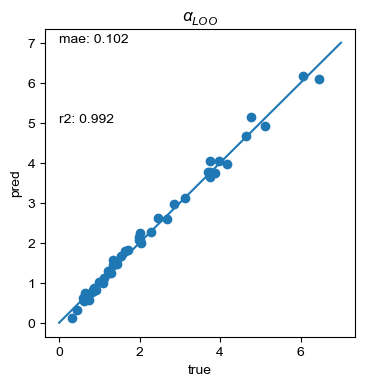

In [51]:
import matplotlib.pyplot as plt
fig, ax =  plt.subplots(figsize=(4, 4))
yy=np.array([0, 7])
ax.plot(yy, yy)
ax.set(title=r"$\alpha_{LOO}$",
      xlabel="true",
      ylabel="pred"
      )
ax.scatter(y_alpha, y_pred_loo_alpha)
ax.text(0, 7, f"mae: {mae:.3f}")
ax.text(0, 5, f"r2: {r2:.3f}")
# plt.savefig(f"yy_plot_alpha_LOO_{datetime.date.today()}.pdf")
# plt.savefig(f"yy_plot_alpha_LOO_{datetime.date.today()}.svg")
plt.show()
plt.clf()
plt.close()


In [52]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.datasets import load_diabetes

# 1. preparation of data
X_V = df_V_collector
y_V = V

# 2. defining regression model
model_V_scikit = LinearRegression()
loo = LeaveOneOut()

# 3. Leave-one-out
scores = cross_val_score(model_V_scikit, X_V, y_V, cv=loo, scoring='neg_mean_squared_error')

# 4. output
print(f"LOO MSE: {-scores.mean():.4f}")
y_pred_loo_V = cross_val_predict(model_V_scikit, X_V, y_V, cv=loo)


mae = mean_absolute_error(y_V, y_pred_loo_V)
r2 = r2_score(y_V, y_pred_loo_V)

print(f"LOO MAE: {mae:.4f}")
print(f"LOO R2 : {r2:.4f}")


LOO MSE: 40.0443
LOO MAE: 4.7604
LOO R2 : 0.9947


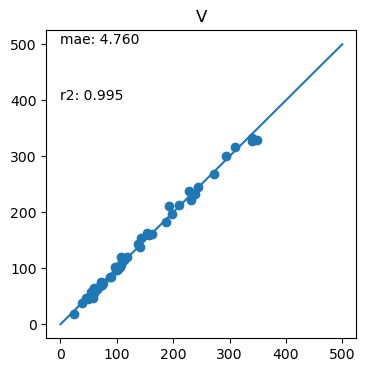

In [36]:
import matplotlib.pyplot as plt
fig, ax =  plt.subplots(figsize=(4, 4))
yy=np.array([0, 500])
ax.plot(yy, yy)
ax.scatter(y_V, y_pred_loo_V)
ax.set_title("V")
ax.text(0, 500,  f"mae: {mae:.3f}")
ax.text(0, 400,  f"r2: {r2:.3f}")
# plt.savefig(f"yy_plot_V_LOO_{datetime.date.today()}.pdf")
# plt.savefig(f"yy_plot_V_LOO_{datetime.date.today()}.svg")
plt.show()
plt.clf()
plt.close()


## $n_D$

In [37]:
data["refractive_index"].isna()

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8     False
9     False
10    False
11    False
12    False
13    False
14    False
15    False
16    False
17    False
18    False
19    False
20    False
21    False
22    False
23    False
24    False
25    False
26    False
27    False
28    False
29    False
30    False
31    False
32    False
33    False
34    False
35    False
36    False
37    False
38    False
39    False
40    False
41    False
42    False
43    False
44    False
45    False
46    False
47    False
48    False
49    False
50    False
Name: refractive_index, dtype: bool

In [38]:
data_test = data_test.rename(columns={"Experimental n": "refractive_index"})

In [39]:
data = pd.concat([data_train, data_test])
data = data.reset_index(drop=True)
data

,SMILES,refractive_index,density,Unnamed: 0,title,Predicted density,reference
0,[*]C(C(O[*])=O)C,1.4700,1.2600,NaN,NaN,NaN,NaN
1,[*]C(C)(C)C[*],1.5075,0.8750,NaN,NaN,NaN,NaN
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050,NaN,NaN,NaN,NaN
3,[*]C/C=C(C[*])\C,1.5150,0.9050,NaN,NaN,NaN,NaN
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900,NaN,NaN,NaN,NaN
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700,NaN,NaN,NaN,NaN
6,[*]CC([*])c1ccccc1,1.5250,1.0500,NaN,NaN,NaN,NaN
7,[*]CC(C=C)[*],1.5400,0.9100,NaN,NaN,NaN,NaN
8,[*]CO[*],1.4950,1.2250,NaN,NaN,NaN,NaN
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650,NaN,NaN,NaN,NaN


In [40]:
n_d_true = data["refractive_index"]
constant=23.0
alpha_over_V_pred = (y_pred_loo_alpha/y_pred_loo_V)*constant
upper = 1 + 2*alpha_over_V_pred
lower = 1 - 1*alpha_over_V_pred
nD_pred = np.sqrt(upper/lower)



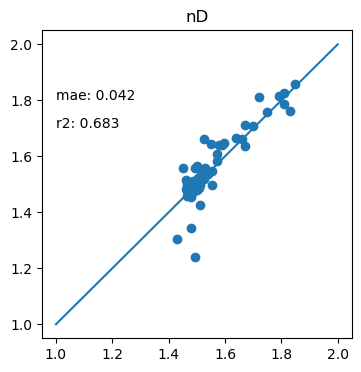

In [41]:
import matplotlib.pyplot as plt
fig, ax =  plt.subplots(figsize=(4, 4))
yy=np.array([1, 2])
ax.plot(yy, yy)
ax.scatter(n_d_true, nD_pred)
ax.set_title("nD")
mae = mean_absolute_error(n_d_true, nD_pred)
r2 = r2_score(n_d_true, nD_pred)
ax.text(1, 1.8,  f"mae: {mae:.3f}")
ax.text(1, 1.7,  f"r2: {r2:.3f}")
plt.savefig(f"yy_plot_nD_LOO_{datetime.date.today()}.pdf")
plt.savefig(f"yy_plot_nD_LOO_{datetime.date.today()}.svg")
plt.show()
plt.clf()
plt.close()


In [42]:
data["loo_pred"]=nD_pred

,SMILES,refractive_index,density,Unnamed: 0,title,Predicted density,reference,loo_pred
0,[*]C(C(O[*])=O)C,1.4700,1.2600,NaN,NaN,NaN,NaN,1.506436
1,[*]C(C)(C)C[*],1.5075,0.8750,NaN,NaN,NaN,NaN,1.487712
2,[*]C(c1ccc(C(OCCO[*])=O)cc1)=O,1.5700,1.4050,NaN,NaN,NaN,NaN,1.607982
3,[*]C/C=C(C[*])\C,1.5150,0.9050,NaN,NaN,NaN,NaN,1.546568
4,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(c4ccc(O[*])cc4)cc3...,1.6700,1.2900,NaN,NaN,NaN,NaN,1.635336
5,[*]c1ccc(S(=O)(c2ccc(Oc3ccc(S(=O)(c4ccc(O[*])c...,1.5500,1.3700,NaN,NaN,NaN,NaN,1.643094
6,[*]CC([*])c1ccccc1,1.5250,1.0500,NaN,NaN,NaN,NaN,1.660601
7,[*]CC(C=C)[*],1.5400,0.9100,NaN,NaN,NaN,NaN,1.541391
8,[*]CO[*],1.4950,1.2250,NaN,NaN,NaN,NaN,1.239330
9,[*]Oc1ccc(Oc2ccc(C(c3ccc([*])cc3)=O)cc2)cc1,1.6700,1.2650,NaN,NaN,NaN,NaN,1.710007


In [43]:
data2=data.copy()
data2 =data2[(data2["refractive_index"]>1.4)&(data2["loo_pred"]>1.4)]
len(data2)

48

In [44]:
data3=data.copy()
data3 =data3[(data3["refractive_index"]>1.4)&(data3["loo_pred"]<1.4)]
len(data3)

3

In [45]:
data3=data.copy()
data3 =data3[(data3["refractive_index"]>1.4)&(data3["loo_pred"]<1.4)]
len(data3)

3

In [46]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
import numpy as np
from matplotlib.ticker import NullFormatter, FixedLocator, AutoMinorLocator, MultipleLocator
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
mpl.rcParams['font.sans-serif'] = ["Arial"]
mpl.rcParams["mathtext.fontset"]="custom"
plt.rcParams['mathtext.sf'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial'
plt.rcParams["mathtext.bf"]  = 'Arial'
plt.rcParams["mathtext.bfit"]= 'Arial'
plt.rcParams["mathtext.cal"]= 'Arial'

plt.rcParams["mathtext.rm"]= 'Arial'
plt.rcParams["mathtext.sf"]= 'Arial'
plt.rcParams["mathtext.tt"]= 'Arial'

mpl.rcParams['font.weight'] = "normal"


from sklearn.metrics import mean_absolute_error, r2_score
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib
from matplotlib.ticker import NullFormatter, FixedLocator, AutoMinorLocator, MultipleLocator
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
import seaborn as sns
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from matplotlib.colors import Normalize
colormapimported = mpl.colormaps['tab20c'].resampled(20)
matplotlib.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['mathtext.sf'] = 'Arial'

matplotlib.rcParams['font.weight'] = "normal"

font = {'family': 'arial',
        'color':  'black',
        'weight': 'normal',
        # 'weight': 'bold',
        'size': 20}
font_title = {'family': 'arial',
        # 'color':  'black',
        'weight': 'normal',
        # 'weight': 'bold',
        'size': 15}
fontforlegend= {'family': 'arial',
#         'color':  'black',
                'weight': 'normal',
                # 'weight': 'bold',
                "size":15}

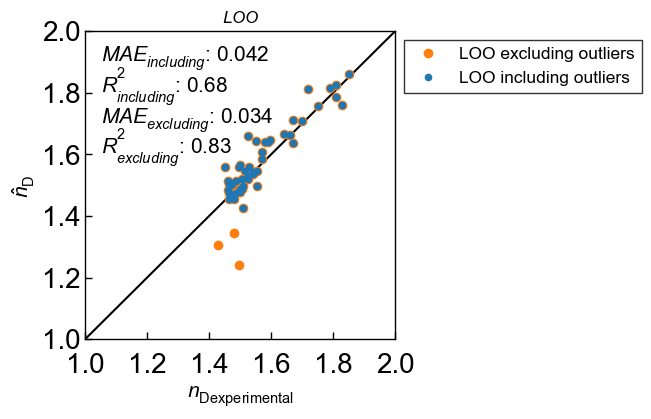

In [47]:
n_d_true = data["refractive_index"]
constant=23
ms_input = 6
alpha_over_V_pred = (y_pred_loo_alpha/y_pred_loo_V)*constant
upper = 1 + 2*alpha_over_V_pred
lower = 1 - 1*alpha_over_V_pred
nD_pred = np.sqrt(upper/lower)
import matplotlib.pyplot as plt
fig, ax =  plt.subplots(figsize=(4, 4))
yy=np.array([1, 2])
ax.plot(yy, yy, c="black")
ax.plot(data["refractive_index"], data["loo_pred"],
        "o",
        label="LOO excluding outliers",
        gapcolor="white", ms=ms_input*1,
        lw=1.5,
        c="C1",

       )
ax.plot(data2["refractive_index"], data2["loo_pred"],
        "o",
        label="LOO including outliers",
        gapcolor="white", ms=ms_input*0.75,
        lw=1.5,
        c="C0",
       )


ax.set_title(r"$\mathit{LOO}$")
mae_without = mean_absolute_error(data2["refractive_index"], data2["loo_pred"])
mae_with = mean_absolute_error(data["refractive_index"], data["loo_pred"])
r2_without = r2_score(data2["refractive_index"], data2["loo_pred"])
r2_with = r2_score(data["refractive_index"], data["loo_pred"])

ax.text(1.05, 1.9,  rf"$\mathit{{MAE}}_{{including}}$: {mae_with:.3f}", color="black", font=font_title)
ax.text(1.05, 1.8,  rf"$\mathit{{R}}^{{2}}_{{including}}$: {r2_with:.2f}", color="black", font=font_title)
ax.text(1.05, 1.7,  rf"$\mathit{{MAE}}_{{excluding}}$: {mae_without:.3f}", color="black", font=font_title)
ax.text(1.05, 1.6,  rf"$\mathit{{R}}^{{2}}_{{excluding}}$: {r2_without:.2f}", color="black", font=font_title)

ax.tick_params(which="major", axis="x",direction="in", left="off",labelleft="on", length=5, width=1, color="black", labelsize=20, labelbottom=10, pad=10)
ax.tick_params(which="major", axis="y",direction="in", left="off",labelleft="on", length=5, width=1, color="black", labelsize=20, labelbottom=10, pad=3)
ax.yaxis.set_major_locator(FixedLocator(np.arange(1, 2+1, 0.2)))
ax.xaxis.set_major_locator(FixedLocator(np.arange(1, 2+1, 0.2)))
ax.spines['right'].set_visible(True)
ax.spines['right'].set_linewidth(1)
ax.spines['top'].set_visible(True)
ax.spines['top'].set_linewidth(1)
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_linewidth(1)
ax.spines['left'].set_visible(True)
ax.spines['left'].set_linewidth(1)
ax.set_xlim(1, 2)
ax.set_ylim(1, 2)
ax.set_xlabel(r"$\mathit{n}\mathsf{_{D experimental}}$", font=font_title)
ax.set_ylabel(r"$\hat{\mathit{n}}\mathsf{_{D}}$ ", font=font_title)

ax.axes.yaxis.set_visible(True)
ax.axes.xaxis.set_visible(True)

ax.legend(bbox_to_anchor=(1, 1),
          edgecolor="black",
          fancybox=False,
          prop={"family":"Arial",
                       # "weight":"bold",
                       "weight":"normal",
                       "size": "12.5"},)

# plt.savefig(f"yy_plot_nD_LOO_colored{datetime.date.today()}.pdf", bbox_inches="tight")
# plt.savefig(f"yy_plot_nD_LOO_colored{datetime.date.today()}.svg", bbox_inches="tight")
plt.show()
plt.clf()
plt.close()

